## Análise Exploratória de Dados (EDA)

Importando as bibliotecas:

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

Lendo os dados tratados anteriormente:

In [37]:
ids_por_bairro = pd.read_csv('../dados_tratados/ids_por_bairro_rj_tratado.csv', encoding='utf-8')
matriz_lb = pd.read_csv('../dados_tratados/matriz_linha_bairro_tratado.csv', encoding='utf-8')
sumario = pd.read_csv('../dados_tratados/sumario_servico_dia_tipo_tratado.csv', encoding='utf-8')
lotacao = pd.read_csv('../dados_tratados/lotacao_onibus_tratado.csv', encoding='utf-8')

### Cruzamentos

Cruzando a tabela de lotação (passageiros) com o sumário (quilometragem/cumprimento), e, em seguida, classificando as linhas com base na região dominante:

In [38]:
df = lotacao.merge(sumario, on=['servico', 'data'], how='inner')    # merge de lotacao e sumario onde servico e data iguais em ambos
df['servico'] = df['servico'].astype(str)                           # colocar a linha do onibus como string

# para cada linha, pegar a região mais frequente entre todos os bairros dela
regiao_por_linha = (
    matriz_lb[matriz_lb['regiao'] != 'Não identificado']
    .groupby('linha')['regiao']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'linha': 'servico'}) # renomear só aqui para o merge
)

regiao_por_linha['servico'] = regiao_por_linha['servico'].astype(str)

df = df.merge(regiao_por_linha, on='servico', how='left')           # merge left, encaixa o regiao por linha no df mesmo se não tiver correspondente no região por linha
df['regiao'] = df['regiao'].fillna('Não identificado')              # preenche os nan com nao identificado



Consolidando os dados operacionais em médias e totais mensais por região e calculando a métrica de passageiros por viagem. Exibindo também o top 5 linhas com maior valor calculado para essa métrica:

In [39]:
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.to_period('M')                            # cria nova coluna mês, que só pega o ano e o mês da data (2023-07-25 → 2023-07)
# agrupa pelos os que tem o msm servico(linha), mes e regiao
# agg(coluna=('colunax','método') cria colunas novas usando colunas do df mensal agrupado e fazendo alguma operação, unique conta valores unicos, mean média, sum soma tudo)
df_mensal = df.groupby(['servico', 'mes', 'regiao']).agg(
    passageiros_total=('qtd_passageiros_total', 'sum'),
    viagens_total=('qtd_viagens', 'sum'),
    cumprimento=('perc_km_planejada', 'mean')).reset_index()
df_mensal['passageiros_por_viagem']=(df_mensal['passageiros_total']/df_mensal['viagens_total'].replace(0, None)) # adiciona essa coluna passageiros por viagens usando a coluna do df viagens total que acabou de ser criada

# limpeza simples onde tira outliers absurdos
df_mensal = df_mensal[df_mensal['passageiros_por_viagem'] <= 250]
df_mensal = df_mensal[~((df_mensal['cumprimento'] < 10) & (df_mensal['viagens_total'] > 0))]
df_mensal = df_mensal[df_mensal['cumprimento'] <= 300]
df_mensal = df_mensal.sort_values(by='cumprimento', axis=0, ascending=True, inplace=False, na_position='last', ignore_index=False)

colunas_mensal = ['servico', 'mes', 'regiao', 'passageiros_por_viagem', 'cumprimento']
df_mensal[colunas_mensal].sort_values('passageiros_por_viagem', ascending=False).head().style.set_caption("Top 5 linhas com mais passageiros por viagem e o mês correspondente").hide(axis='index')

servico,mes,regiao,passageiros_por_viagem,cumprimento
693,2022-10,Zona Oeste,247.452381,110.898571
385,2023-10,Zona Norte / Subúrbio,246.166667,107.017895
265,2023-06,Zona Norte / Subúrbio,246.040650,89.620400
663,2024-07,Zona Norte / Subúrbio,244.525000,100.000000
SP309,2023-02,Zona Sul,243.714286,75.000000


### Análise de lotação comparada com o cumprimento de viagens

In [41]:
df.nunique()

servico                    403
mes                         27
regiao                       4
passageiros_total         8009
viagens_total             3619
cumprimento               7991
passageiros_por_viagem    8164
dtype: int64

In [42]:
df_mensal.info()

<class 'pandas.DataFrame'>
Index: 8178 entries, 7775 to 2747
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   servico                 8178 non-null   str      
 1   mes                     8178 non-null   period[M]
 2   regiao                  8178 non-null   str      
 3   passageiros_total       8178 non-null   int64    
 4   viagens_total           8178 non-null   int64    
 5   cumprimento             8178 non-null   float64  
 6   passageiros_por_viagem  8178 non-null   float64  
dtypes: float64(2), int64(2), period[M](1), str(2)
memory usage: 658.3 KB


In [43]:
ranking = df_mensal.groupby(['servico','regiao']).agg(
    meses=('mes','nunique'),
    cumprimento_medio=('cumprimento','mean'),
    passageiros_por_viagem=('passageiros_por_viagem','mean'),
    total_passageiros=('passageiros_total','sum')
).reset_index()

ranking = ranking[ranking['meses'] >= 10]                                               # amostra de 10 meses pra cima
ranking = ranking.sort_values('cumprimento_medio').head(20).reset_index(drop=True)      # só mostra os 20 primeiros
ranking.index+= 1
ranking.insert(0, 'periodo', PERIODO)
ranking = ranking.round(1)

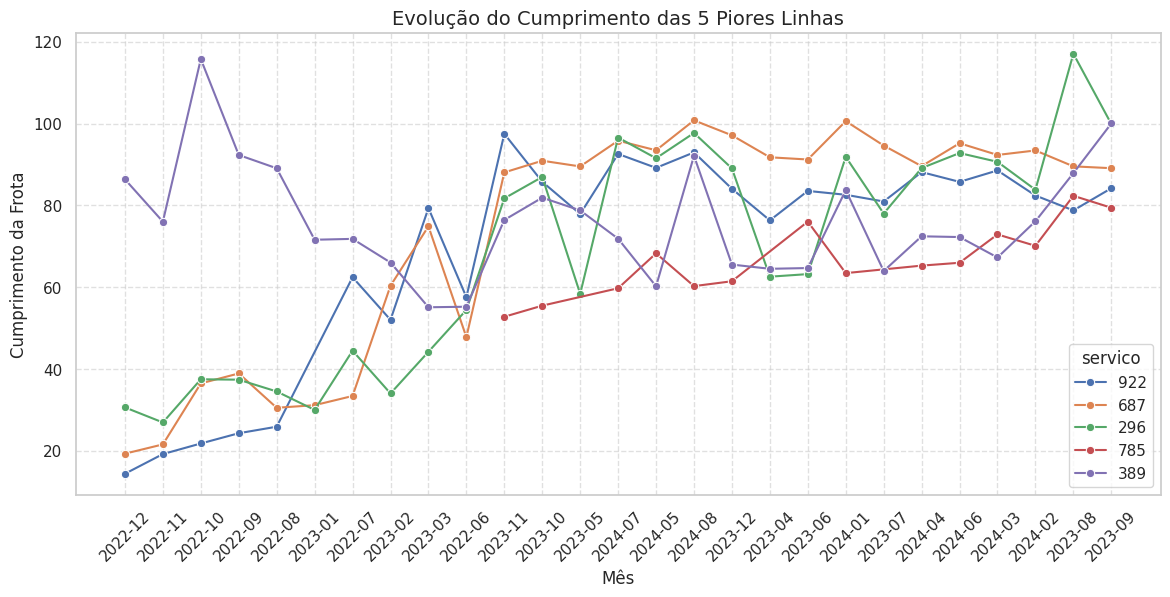

In [44]:
top_5_piores = ranking['servico'].head(5).tolist()
df_piores = df_mensal[df_mensal['servico'].isin(top_5_piores)]
df_piores['mes_str'] = df_piores['mes'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_piores, x='mes_str', y='cumprimento', hue='servico', marker='o')
plt.title('Evolução do Cumprimento das 5 Piores Linhas', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Cumprimento da Frota')
plt.xlabel('Mês')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

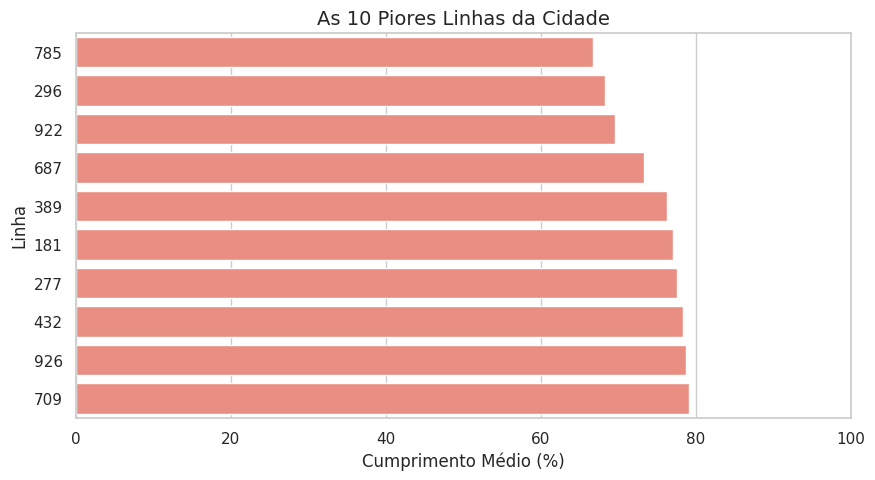

In [45]:
top_10 = ranking.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='cumprimento_medio', y='servico', color='salmon')
plt.title('As 10 Piores Linhas da Cidade', fontsize=14)
plt.xlabel('Cumprimento Médio (%)')
plt.ylabel('Linha')
plt.xlim(0, 100) 
plt.show()

### Análise de lotação comparada com indicativos sociais

O gráfico abaixo mostra a lotação (ou seja, a média do índice de passageiros por viagem) por bairro, em que o eixo x dos bairros está ordenado em ordem crescente de IDS. Considera-se, para que possamos comparar a precariedade social com a lotação do transporte, que os bairros da esquerda são considerados menos nobres que os da direita.

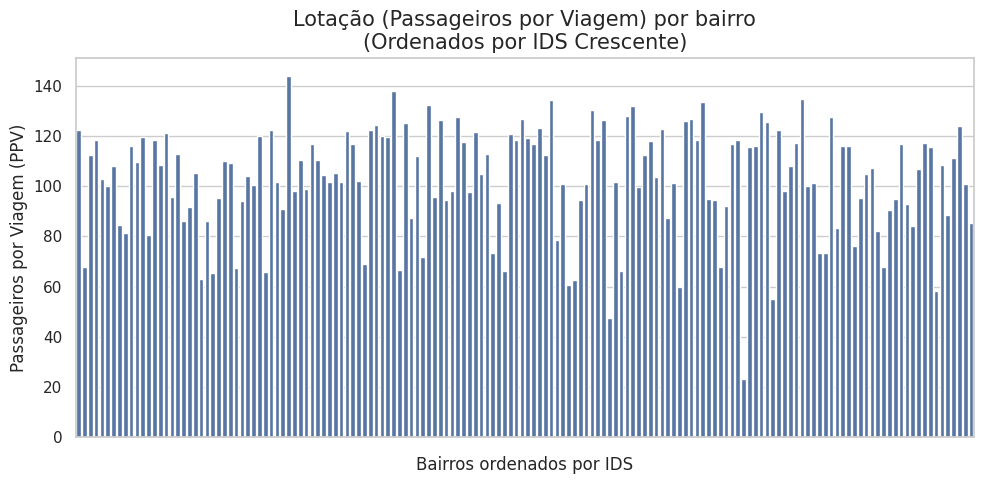

In [62]:
df_plot = ids_por_bairro.dropna(subset=['passageiros_por_viagem'])

# ordenando ids em ordem crescente
df_plot = df_plot.sort_values('ids')

plt.figure(figsize=(10, 5))
grafico = sns.barplot(
    data=df_plot, 
    x='bairro', 
    y='passageiros_por_viagem'
)

plt.title('Lotação (Passageiros por Viagem) por bairro\n(Ordenados por IDS Crescente)', fontsize=15)
plt.xlabel('Bairros ordenados por IDS', fontsize=12)
plt.ylabel('Passageiros por Viagem (PPV)', fontsize=12)


grafico.set(xticklabels=[])

plt.tight_layout()
plt.show()

Vemos, assim, que essa relação é estatísticamente insignificante e o problema de superlotação afeta a cidade do Rio independentemente do nível de desenvolvimento social local.

### Boxplots gerais

<Figure size 640x480 with 0 Axes>

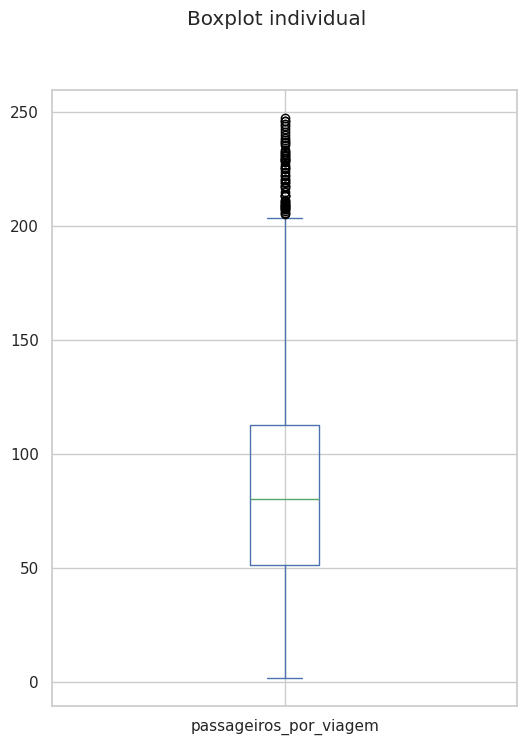

<Figure size 640x480 with 0 Axes>

In [46]:
df_mensal[['passageiros_por_viagem']].plot(kind='box', subplots=True, title="Boxplot individual", figsize=(6, 8))
plt.figure()

<Figure size 640x480 with 0 Axes>

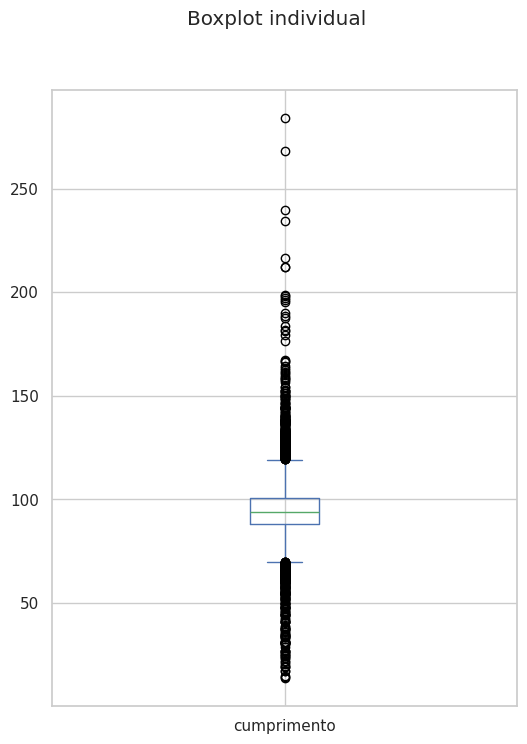

<Figure size 640x480 with 0 Axes>

In [47]:
df_mensal[['cumprimento']].plot(kind='box', subplots=True, title="Boxplot individual", figsize=(6, 8))
plt.figure()

<Figure size 640x480 with 0 Axes>

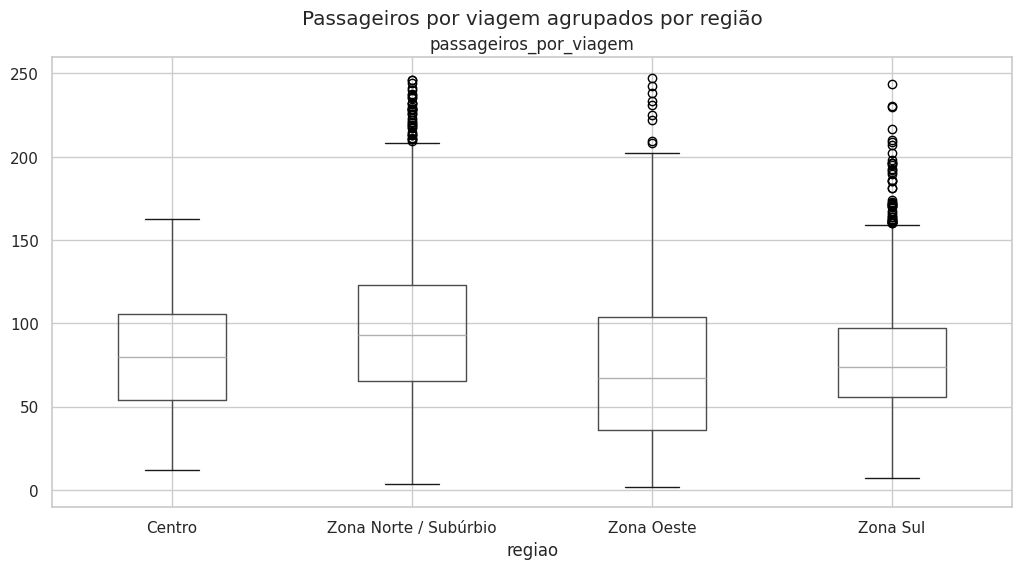

<Figure size 640x480 with 0 Axes>

In [48]:
df_mensal.boxplot(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.suptitle('Passageiros por viagem agrupados por região')

plt.figure()

<Figure size 640x480 with 0 Axes>

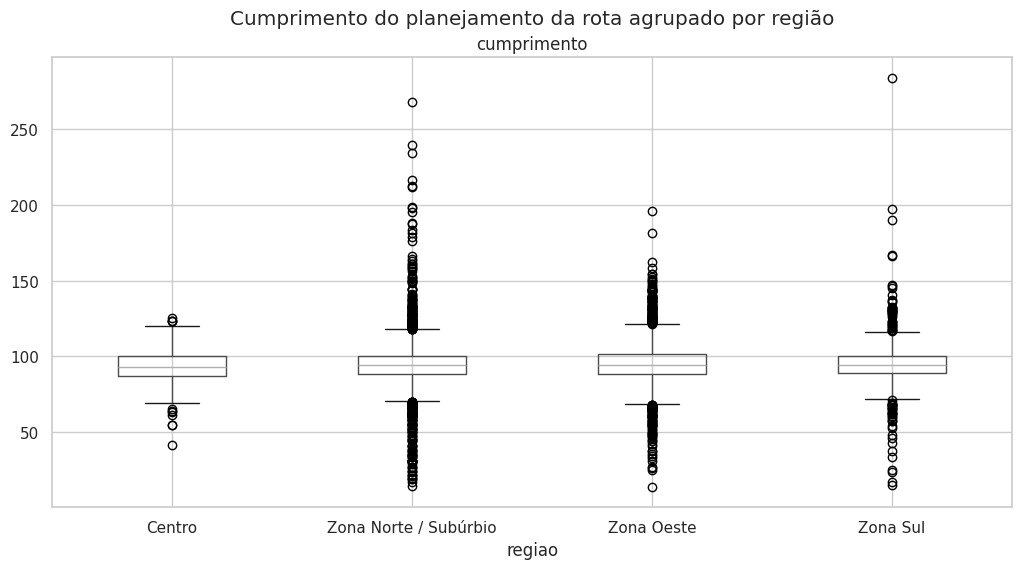

<Figure size 640x480 with 0 Axes>

In [49]:
df_mensal.boxplot(column='cumprimento', by='regiao', figsize=(12, 6))
plt.suptitle('Cumprimento do planejamento da rota agrupado por região')
plt.figure()

### Histogramas gerais

<Figure size 640x480 with 0 Axes>

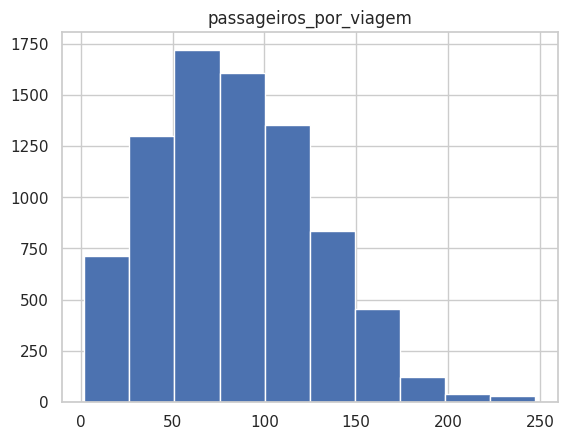

<Figure size 640x480 with 0 Axes>

In [50]:
df_mensal[['passageiros_por_viagem']].hist()
plt.figure()

<Figure size 640x480 with 0 Axes>

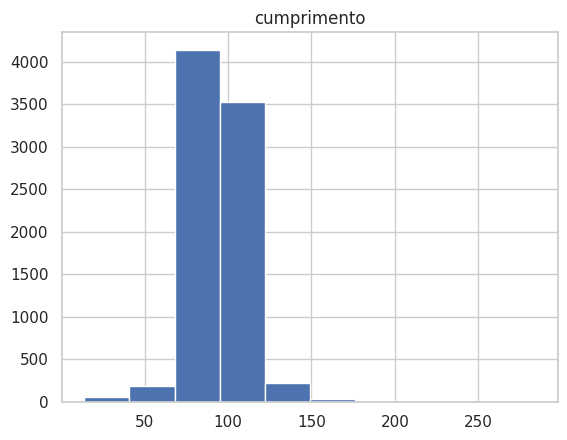

<Figure size 640x480 with 0 Axes>

In [51]:
df_mensal[['cumprimento']].hist()
plt.figure()

<Figure size 640x480 with 0 Axes>

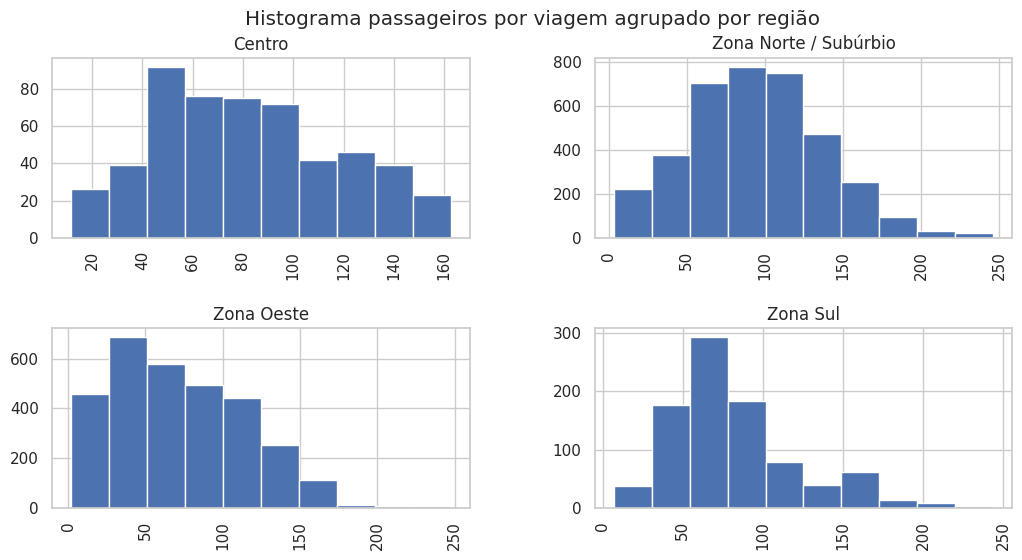

<Figure size 640x480 with 0 Axes>

In [52]:
df_mensal.hist(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.suptitle('Histograma passageiros por viagem agrupado por região')
plt.figure()

<Figure size 640x480 with 0 Axes>

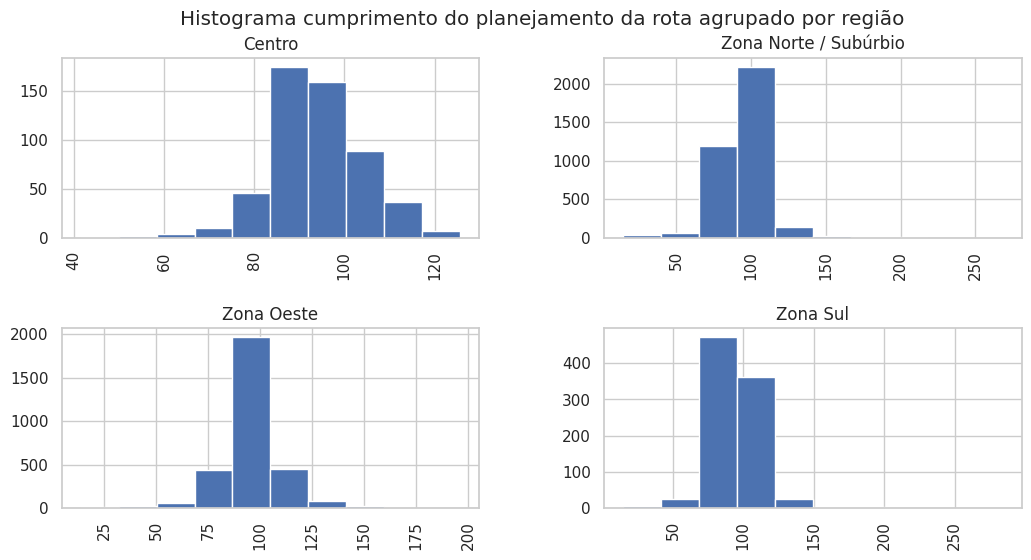

<Figure size 640x480 with 0 Axes>

In [53]:
df_mensal.hist(column='cumprimento', by='regiao', figsize=(12, 6))
plt.suptitle('Histograma cumprimento do planejamento da rota agrupado por região')
plt.figure()

<Figure size 640x480 with 0 Axes>

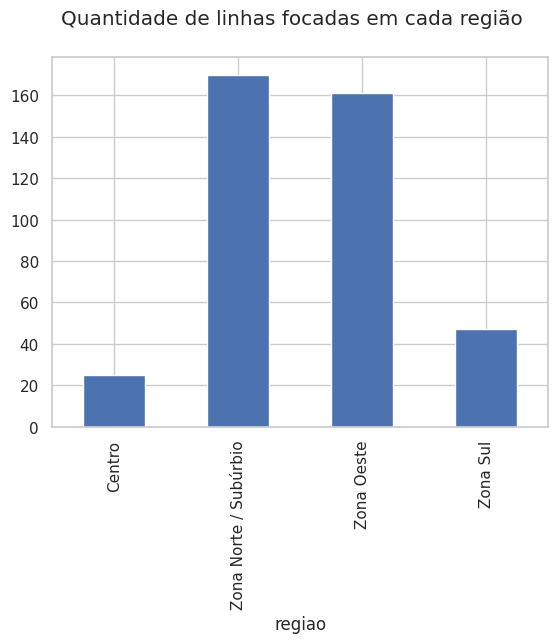

<Figure size 640x480 with 0 Axes>

In [54]:
df_mensal.groupby('regiao')['servico'].nunique().plot(kind='bar')
plt.suptitle('Quantidade de linhas focadas em cada região')
plt.figure()

### Gráfico de dispersão

Text(0.5, 1.0, 'Dispersão de passageiros e viagens totais de cada linha')

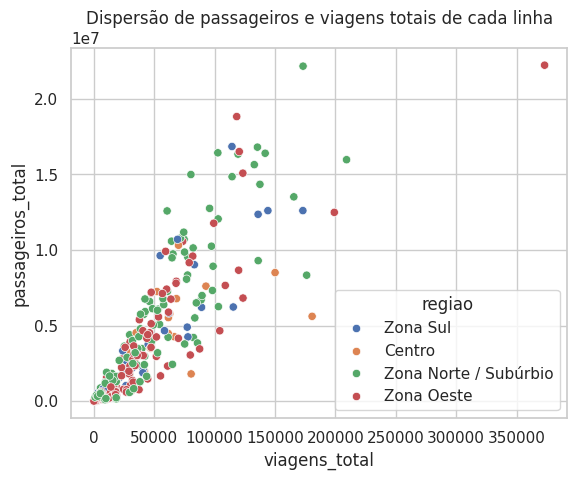

In [55]:
df_agrupado = df_mensal[['regiao', 'servico', 'passageiros_total', 'viagens_total']].groupby(['servico', 'regiao'])[['passageiros_total', 'viagens_total']].sum()
sns.scatterplot(x='viagens_total', y='passageiros_total', hue='regiao', data=df_agrupado)
plt.title('Dispersão de passageiros e viagens totais de cada linha')

In [56]:
df_mensal[['viagens_total', 'passageiros_total', 'passageiros_por_viagem', 'cumprimento']].corr()

,viagens_total,passageiros_total,passageiros_por_viagem,cumprimento
viagens_total,1.000000,0.842529,0.132797,0.081910
passageiros_total,0.842529,1.000000,0.497010,0.022349
passageiros_por_viagem,0.132797,0.497010,1.000000,-0.083996
cumprimento,0.081910,0.022349,-0.083996,1.000000


In [57]:
gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson').rename(columns={'nome': 'bairro'}).astype(str)
df_linha_bairro_com_cod = matriz_lb.merge(gdf_bairros[['bairro', 'codbairro']], on='bairro').astype(str)
df_linha_bairro_com_cod['codbairro'] = df_linha_bairro_com_cod['codbairro'].astype(int)
ids_por_bairro['codbairro'] = ids_por_bairro['codbairro'].astype(int)
df_linha_bairro_ids = df_linha_bairro_com_cod.merge(ids_por_bairro[['codbairro', 'ids']], on='codbairro')
df_linha_bairro_ids = df_linha_bairro_ids.groupby('bairro').agg({
    'codbairro': 'first',
    'ids': 'first',
    'regiao': 'first',
    'linha': 'nunique' 
}).rename(columns={'linha': 'qtd_linhas'}).reset_index()
df_linha_bairro_ids.head(157)


,bairro,codbairro,ids,regiao,qtd_linhas
0,Abolição,70,0.613303,Zona Norte / Subúrbio,24
1,Acari,111,0.512086,Zona Norte / Subúrbio,34
2,Alto da Boa Vista,34,0.524369,Zona Norte / Subúrbio,5
3,Anchieta,107,0.554227,Zona Oeste,19
4,Andaraí,37,0.644252,Zona Norte / Subúrbio,15
...,...,...,...,...,...
152,Vila Valqueire,125,0.635159,Zona Oeste,23
153,Vila da Penha,74,0.640781,Zona Norte / Subúrbio,18
154,Vista Alegre,75,0.620438,Zona Norte / Subúrbio,12
155,Zumbi,92,0.660360,Zona Norte / Subúrbio,9


Text(0.5, 1.0, 'Dispersão de ids e nº de linhas que passam em um bairro')

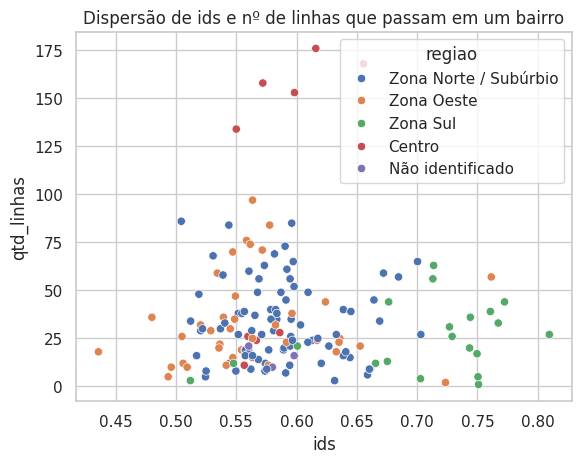

In [58]:
sns.scatterplot(x='ids', y='qtd_linhas', hue='regiao', data=df_linha_bairro_ids)
plt.title('Dispersão de ids e nº de linhas que passam em um bairro')

### Mapa Interativo

Criando um mapa interativo e salvando em html na pasta *dados_tratados*:

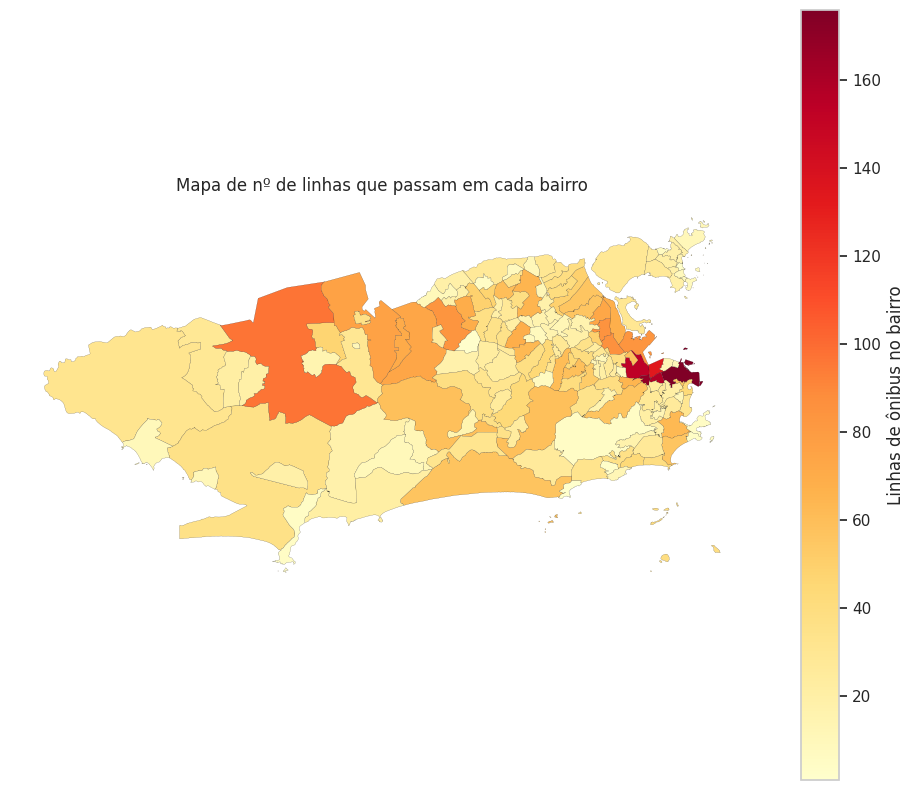

In [59]:
contagem_linhas = matriz_lb.groupby('bairro')['linha'].nunique().reset_index()
contagem_linhas = contagem_linhas.rename(columns={'linha': 'quantidade_linhas'})

gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson')
mapa_linhas = gdf_bairros.merge(contagem_linhas, left_on='nome', right_on='bairro', how='left')

mapa_linhas['quantidade_linhas'] = mapa_linhas['quantidade_linhas']
mapa_linhas = gpd.GeoDataFrame(mapa_linhas, geometry='geometry')
mapa_linhas = mapa_linhas.to_crs(4326)

mapa_linhas.plot(column='quantidade_linhas', cmap='YlOrRd', linewidth=0.1, edgecolor='black', legend=True, legend_kwds={'label': "Linhas de ônibus no bairro", 'orientation': "vertical"}, figsize=(12, 10)).set_axis_off()
plt.title('Mapa de nº de linhas que passam em cada bairro')

mapa_interativo = mapa_linhas.explore(
    column='quantidade_linhas',
    cmap='YlOrRd',
    tooltip=['bairro', 'quantidade_linhas'], 
    legend_name='Total de Linhas',
    tiles='CartoDB positron'
)

mapa_interativo.save("../dados_tratados/mapa_interativo.html")

### Evolução da lotação ao longo do tempo

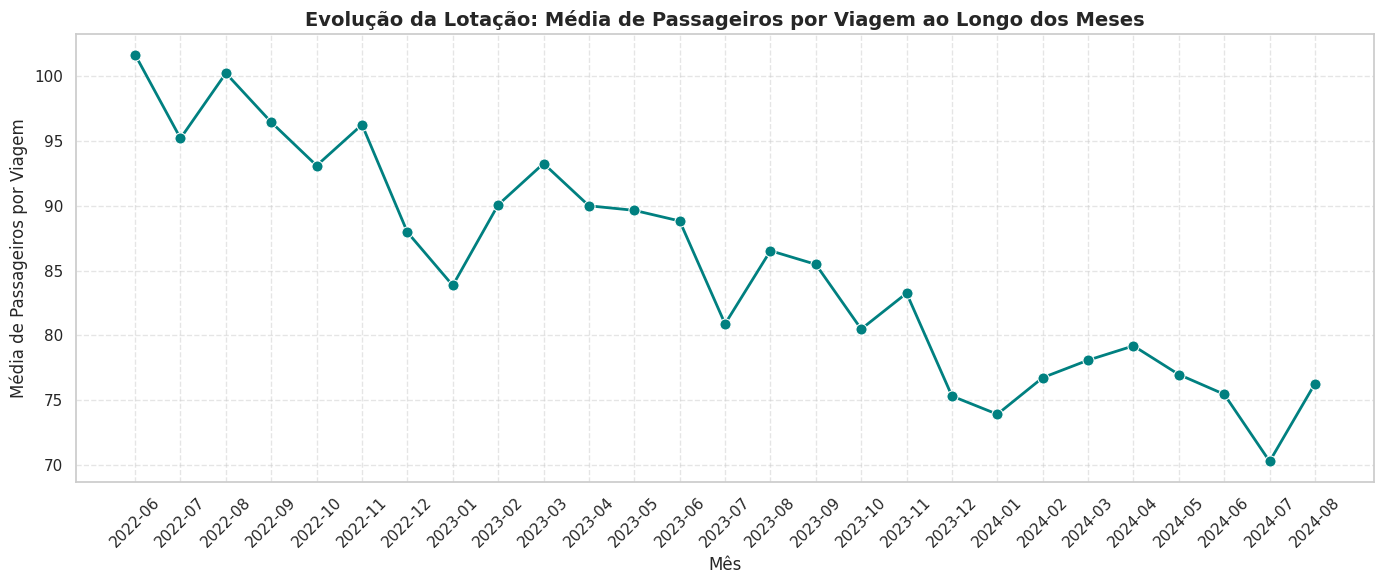

In [60]:
df_evolucao_lota = df_mensal.groupby('mes')['passageiros_por_viagem'].mean().reset_index()
df_evolucao_lota['mes_str']=df_evolucao_lota['mes'].astype(str)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_evolucao_lota, x='mes_str', y='passageiros_por_viagem', marker='o', color='teal', linewidth=2,markersize=8)
plt.title('Evolução da Lotação: Média de Passageiros por Viagem ao Longo dos Meses', fontsize=14, weight='bold')
plt.xlabel('Mês')
plt.ylabel('Média de Passageiros por Viagem')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

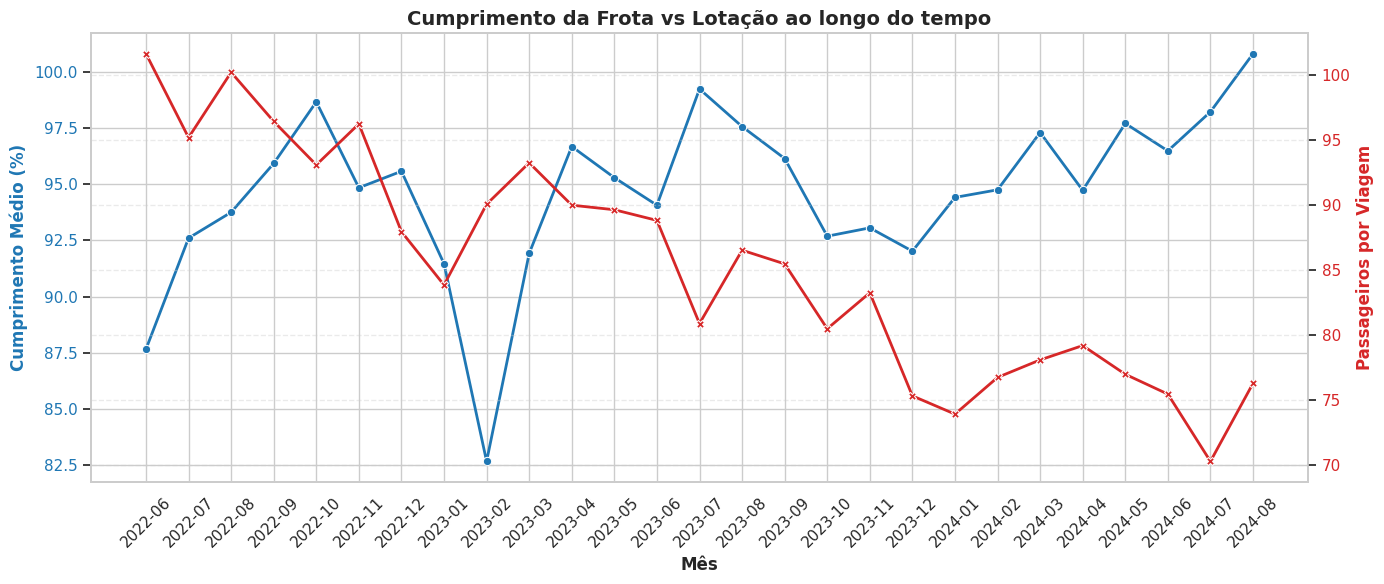

In [61]:
df_tempo = df_mensal.groupby('mes').agg({'cumprimento':'mean','passageiros_por_viagem':'mean'}).reset_index()
df_tempo['mes_str']=df_tempo['mes'].astype(str)
fig, ax1=plt.subplots(figsize=(14, 6))
color='tab:blue'
ax1.set_xlabel('Mês', weight='bold')
ax1.set_ylabel('Cumprimento Médio (%)', color=color, weight='bold')
sns.lineplot(data=df_tempo, x='mes_str', y='cumprimento', marker='o', color=color, ax=ax1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx() 
color='tab:red'
ax2.set_ylabel('Passageiros por Viagem', color=color, weight='bold')
sns.lineplot(data=df_tempo, x='mes_str', y='passageiros_por_viagem', marker='X', color=color, ax=ax2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Cumprimento da Frota vs Lotação ao longo do tempo', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()